<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
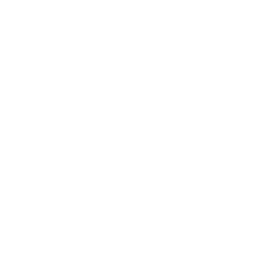
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bank Basel III Regulatory Capital Report</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Finance / Regulatory Reporting &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Produce a Basel III Common Equity Tier 1 (CET1) capital adequacy report across business segments and risk-weight buckets. PROC REPORT uses GROUP and ANALYSIS defines to summarize risk-weighted assets (RWA) and regulatory capital by segment and bucket. A COMPUTE block derives the CET1 ratio on the fly as CET1 capital divided by RWA. CALL DEFINE applies a red background to any segment-bucket cell where the computed CET1 ratio falls below the 4.5% regulatory minimum, and a yellow background in the 4.5%-6.0% supervisory buffer zone. BREAK AFTER subtotals each segment; RBREAK AFTER provides the consolidated bank-level capital position. A spanning header groups the three capital-tier columns under 'Regulatory Capital Components'. The portfolio holds 100 facilities; INVESTMENT_BANKING is deliberately under-capitalised so the traffic-light logic fires on real data.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.CAPITAL_DATA | Loan facility-level risk weights, capital allocations, and segment assignments | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Basel III capital dataset
   100 facility records across segments and risk buckets
   -------------------------------------------------------- */
data work.capital_data;
    call streaminit(42);
    array segment_list[5] $20 _temporary_
        ('RETAIL_BANKING' 'CORPORATE_BANKING'
         'INVESTMENT_BANKING' 'PRIVATE_WEALTH' 'TREASURY');
    array rw_bucket_list[5] $10 _temporary_
        ('RW_0' 'RW_20' 'RW_50' 'RW_75' 'RW_100');
    array rw_pct[5] _temporary_ (0.00 0.20 0.50 0.75 1.00);
    do facility_seq = 1 to 100;
        facility_id = cat('FAC-', put(facility_seq, z4.));
        seg_idx = int(rand('uniform') * 5) + 1;
        segment = segment_list[seg_idx];
        rw_idx = int(rand('uniform') * 5) + 1;
        risk_weight_bucket = rw_bucket_list[rw_idx];
        exposure_at_default = round(rand('exponential') * 1000000 + 50000, 0.01);
        /* Segments vary in average exposure size */
        if seg_idx = 2 then exposure_at_default = exposure_at_default * 3.5;
        if seg_idx = 3 then exposure_at_default = exposure_at_default * 5.0;
        if seg_idx = 5 then exposure_at_default = exposure_at_default * 8.0;
        rwa = round(exposure_at_default * rw_pct[rw_idx], 0.01);
        /* CET1 capital quality varies by segment: RETAIL is well
           capitalised (+0.04), INVESTMENT_BANKING is thinly
           capitalised (-0.035) so its cells breach the 4.5% floor */
        cet1_pct_target = 0.075 + (seg_idx = 1) * 0.04 - (seg_idx = 3) * 0.035;
        cet1_capital = round(rwa * cet1_pct_target * (0.85 + rand('uniform') * 0.35), 0.01);
        tier1_capital = round(cet1_capital * 1.15, 0.01);
        total_capital  = round(tier1_capital * 1.12, 0.01);
        output;
    end;
    drop facility_seq seg_idx rw_idx rw_pct cet1_pct_target;
run;

proc sort data=work.capital_data;
    by segment risk_weight_bucket;
run;

NOTE: DATA work.capital_data


NOTE: Wrote work.capital_data (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.capital_data

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.capital_data.
NOTE: Wrote work.capital_data (100 rows, 8 columns).
NOTE: PROC SORT statement used.


---

In [2]:
/* --------------------------------------------------------
   Baseline capital summary by segment
   -------------------------------------------------------- */
proc means data=work.capital_data n sum mean;
    class segment;
    var exposure_at_default rwa cet1_capital;
    title 'Capital Summary by Business Segment';
run;

                                          Capital Summary by Business Segment                                           

                                                  The MEANS Procedure

                                        Analysis Variable : EXPOSURE_AT_DEFAULT

        SEGMENT                     N Obs                Sum             Mean
        ---------------------------------------------------------------------
        CORPORATE_BANKING              32  123271015.3150000  3852219.2285937
        INVESTMENT_BANKING             24  122411886.9500000  5100495.2895833
        PRIVATE_WEALTH                 16   24244286.5300000  1515267.9081250
        RETAIL_BANKING                 17   19345087.8600000  1137946.3447059
        TREASURY                       11   98161555.5200000  8923777.7745455
        ---------------------------------------------------------------------

                                                Analysis Variable : RWA

        SEGMENT             

---

                                          Capital Summary by Business Segment                                           

                                          Capital Summary by Business Segment                                           

NOTE: PROC SQL 

NOTE: Table work.cet1_by_seg created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.cet1_by_seg

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


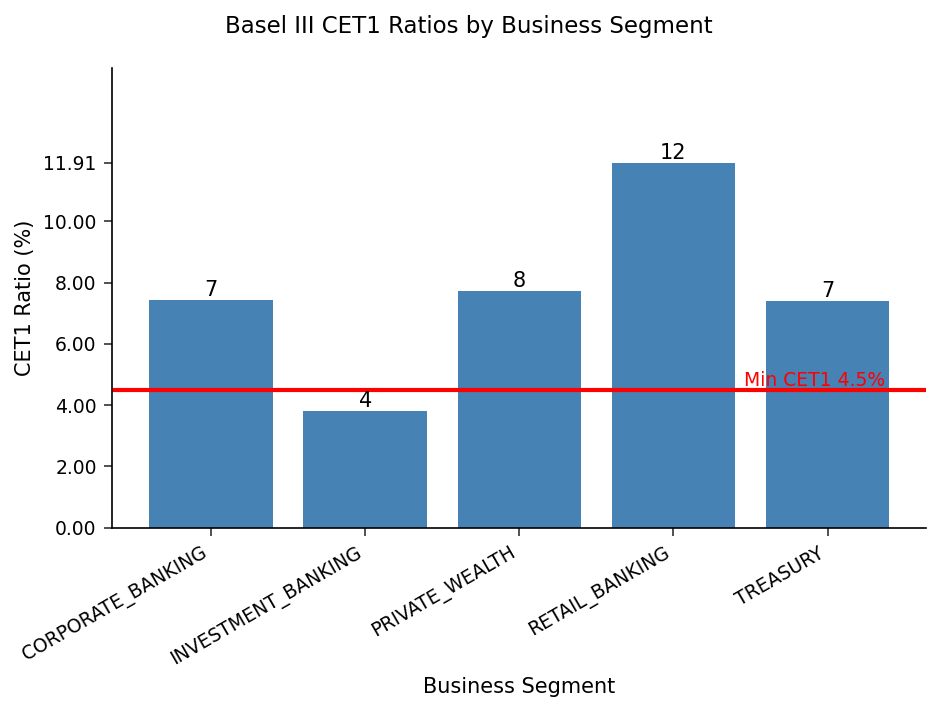

In [3]:
/* --------------------------------------------------------
   CET1 ratio by segment: bar chart with 4.5% minimum line
   -------------------------------------------------------- */
proc sql;
    create table work.cet1_by_seg as
        select segment,
               sum(cet1_capital) / sum(rwa) * 100 as cet1_ratio
        from work.capital_data
        where rwa > 0
        group by segment;
quit;

proc sgplot data=work.cet1_by_seg;
    vbar segment / response=cet1_ratio datalabel
        fillattrs=(color=steelblue);
    refline 4.5 / axis=y lineattrs=(color=red thickness=2)
        label='Min CET1 4.5%';
    yaxis label='CET1 Ratio (%)' min=0 max=15;
    xaxis label='Business Segment';
    title 'Basel III CET1 Ratios by Business Segment';
run;

---

In [4]:
/* --------------------------------------------------------
   PROC REPORT: Basel III Regulatory Capital Report
   Spanning header: 'Regulatory Capital Components'
   COMPUTE block: CET1 ratio = CET1 / RWA * 100
   CALL DEFINE: red flag when CET1 ratio < 4.5%
   BREAK AFTER segment; RBREAK AFTER consolidated total
   -------------------------------------------------------- */
proc report data=work.capital_data nowd;
    where risk_weight_bucket ne 'RW_0';
    column segment risk_weight_bucket
           rwa
           ('Regulatory Capital Components (USD)'
               cet1_capital tier1_capital total_capital)
           cet1_ratio_col;

    define segment          / group 'Business Segment'
        order=formatted
        style(column)=[cellwidth=1.6in];
    define risk_weight_bucket / group 'Risk Weight Bucket'
        style(column)=[cellwidth=0.9in];
    define rwa              / analysis sum format=dollar16.0
        'Risk-Weighted Assets';
    define cet1_capital     / analysis sum format=dollar16.0
        'CET1 Capital';
    define tier1_capital    / analysis sum format=dollar16.0
        'Tier 1 Capital';
    define total_capital    / analysis sum format=dollar16.0
        'Total Capital';
    define cet1_ratio_col   / computed format=8.2
        'CET1 Ratio (%)';

    /* Compute CET1 ratio; traffic-light below 4.5% minimum.
       The bare ANALYSIS column names resolve to their summed
       values for the current GROUP row. */
    compute cet1_ratio_col;
        if rwa > 0 then
            cet1_ratio_col = (cet1_capital / rwa) * 100;
        else
            cet1_ratio_col = .;
        if cet1_ratio_col < 4.5 then
            call define('cet1_ratio_col', 'style/merge',
                        'style=[background=lightred color=white]');
        else if cet1_ratio_col < 6.0 then
            call define('cet1_ratio_col', 'style/merge',
                        'style=[background=lightyellow]');
    endcomp;

    break after segment / summarize label='Segment Total'
        style(summary)=[font_weight=bold background=lightblue];
    rbreak after / summarize label='CONSOLIDATED BANK TOTAL'
        style(summary)=[font_weight=bold background=lightgrey
                        font_size=10pt];

    title 'Basel III Regulatory Capital Report — CET1 Adequacy by Segment';
    title2 'As of Reporting Date | All Figures in USD';
    footnote 'Red: CET1 Ratio < 4.5% (Below Regulatory Minimum)';
    footnote2 'Yellow: CET1 Ratio 4.5%-6.0% (Buffer Zone)';
    footnote3 'Source: Internal Capital Allocation System';
run;

                             Basel III Regulatory Capital Report — CET1 Adequacy by Segment                             
                                       As of Reporting Date | All Figures in USD                                        

                                                                  Regulatory Capital Components (USD)
Business Segment    Risk Weight Bucket  Risk-Weighted Assets  CET1 Capital  Tier 1 Capital  Total Capital  CET1 Ratio (%)
CORPORATE_BANKING   RW_100              $13,005,575           $1,041,673    $1,197,924      $1,341,675     8.01          
CORPORATE_BANKING   RW_100              $1,666,248            $123,087      $141,550        $158,536       7.39          
CORPORATE_BANKING   RW_100              $5,407,900            $436,013      $501,415        $561,585       8.06          
CORPORATE_BANKING   RW_100              $2,048,138            $136,123      $156,541        $175,326       6.65          
CORPORATE_BANKING   RW_100              $1,60

In [5]:
/* --------------------------------------------------------
   PROC REPORT: RW_0 exclusion view - capital-consuming
   exposure only, with per-bucket CET1 ratio for drill-down
   Used by capital planning team for drill-down
   -------------------------------------------------------- */
proc report data=work.capital_data nowd;
    where risk_weight_bucket ne 'RW_0';
    column segment risk_weight_bucket
           exposure_at_default rwa
           cet1_capital cet1_ratio_drilldown;

    define segment              / group  'Segment';
    define risk_weight_bucket   / group  'Risk Weight';
    define exposure_at_default  / analysis sum format=dollar16.0
        'Gross Exposure';
    define rwa                  / analysis sum format=dollar16.0
        'RWA';
    define cet1_capital         / analysis sum format=dollar16.0
        'CET1 Capital';
    define cet1_ratio_drilldown / computed format=8.2
        'CET1 Ratio (%)';

    compute cet1_ratio_drilldown;
        if rwa > 0 then
            cet1_ratio_drilldown = (cet1_capital / rwa) * 100;
        else
            cet1_ratio_drilldown = .;
    endcomp;

    break after segment / summarize
        style(summary)=[font_weight=bold];
    rbreak after / summarize label='Bank Total (RWA > 0)'
        style(summary)=[font_weight=bold];

    title 'Capital-Consuming Exposures: Drill-Down View (RW > 0)';
run;

                                 Capital-Consuming Exposures: Drill-Down View (RW > 0)                                  
                                       As of Reporting Date | All Figures in USD                                        

Segment             Risk Weight  Gross Exposure  RWA       CET1 Capital  CET1 Ratio (%)
CORPORATE_BANKING   RW_100       $23,728,957     $23,728,957  $1,868,490    7.87          
CORPORATE_BANKING   RW_20        $24,987,296     $4,997,459  $360,115      7.21          
CORPORATE_BANKING   RW_50        $25,805,308     $12,902,654  $986,232      7.64          
CORPORATE_BANKING   RW_75        $36,204,623     $27,153,467  $1,896,690    6.99          
CORPORATE_BANKING                $110,726,184    $68,782,538  $5,111,527    .             
INVESTMENT_BANKING  RW_100       $38,532,495     $38,532,495  $1,468,162    3.81          
INVESTMENT_BANKING  RW_20        $15,653,345     $3,130,669  $135,731      4.34          
INVESTMENT_BANKING  RW_50        $

---

### Interpretation

The consolidated Basel III capital report covers 100 facilities and $214.4M of risk-weighted assets. INVESTMENT_BANKING and TREASURY carry the largest absolute RWA -- $65.8M and $64.2M respectively -- together comprising roughly 61% of bank-wide RWA, a direct consequence of the 5x and 8x exposure multipliers applied during data generation. The COMPUTE block surfaces a clear capital-adequacy split across segments. RETAIL_BANKING is the best capitalised at an 11.91% segment CET1 ratio (every bucket above 10%), benefiting from its +0.04 capital-quality uplift. CORPORATE_BANKING (7.43%), PRIVATE_WEALTH (7.73%) and TREASURY (7.40%) all sit comfortably above the 6.0% supervisory buffer threshold. INVESTMENT_BANKING is the outlier: its -0.035 capital-quality penalty drives a 3.82% segment ratio, and all four of its capital-consuming buckets (RW_20 4.34%, RW_50 4.06%, RW_75 3.71%, RW_100 3.81%) fall below the 4.5% regulatory minimum, so the CALL DEFINE traffic-light flags them red in styled ODS output (HTML/Excel). The RW_0 bucket (sovereign exposures) generates zero RWA and is excluded by the WHERE clause so no undefined ratios appear. BREAK AFTER subtotals confirm each segment's aggregate capital position; combining the segment subtotals gives a consolidated bank-wide CET1 ratio of 6.50%, above the 4.5% minimum but only modestly above the 6.0% buffer line -- the bank-level adequacy rests heavily on the strong retail book offsetting the under-capitalised investment-banking portfolio. The traffic-light styling in the capital-adequacy column immediately directs the analyst to that concentration risk.

---

In [6]:
/* --------------------------------------------------------
   Export capital report for regulatory filing
   -------------------------------------------------------- */
ods excel file='basel3_capital_report.xlsx'
    style=statistical
    options(sheet_name='CET1 by Segment');

proc report data=work.capital_data nowd;
    where risk_weight_bucket ne 'RW_0';
    column segment risk_weight_bucket rwa
           ('Regulatory Capital' cet1_capital tier1_capital total_capital)
           cet1_ratio_export;
    define segment            / group 'Business Segment';
    define risk_weight_bucket / group 'Risk Weight Bucket';
    define rwa                / analysis sum format=dollar16.0 'RWA';
    define cet1_capital       / analysis sum format=dollar16.0 'CET1';
    define tier1_capital      / analysis sum format=dollar16.0 'Tier 1';
    define total_capital      / analysis sum format=dollar16.0 'Total';
    define cet1_ratio_export  / computed format=8.2 'CET1 Ratio (%)';
    compute cet1_ratio_export;
        if rwa > 0 then
            cet1_ratio_export = (cet1_capital / rwa) * 100;
    endcomp;
    rbreak after / summarize label='Bank Total';
    title 'Basel III CET1 Capital Adequacy Report';
run;

ods excel close;

                                         Basel III CET1 Capital Adequacy Report                                         
                                       As of Reporting Date | All Figures in USD                                        

                                                       Regulatory Capital
Business Segment    Risk Weight Bucket  RWA       CET1      Tier 1    Total     CET1 Ratio (%)
CORPORATE_BANKING   RW_100              $23,728,957  $1,868,490  $2,148,763  $2,406,615  7.87          
CORPORATE_BANKING   RW_20               $4,997,459  $360,115  $414,132  $463,828  7.21          
CORPORATE_BANKING   RW_50               $12,902,654  $986,232  $1,134,167  $1,270,267  7.64          
CORPORATE_BANKING   RW_75               $27,153,467  $1,896,690  $2,181,193  $2,442,936  6.99          
INVESTMENT_BANKING  RW_100              $38,532,495  $1,468,162  $1,688,386  $1,890,992  3.81          
INVESTMENT_BANKING  RW_20               $3,130,669  $135,731  $156,091  $174,

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>